# Predictive Maintenance — Exploratory Data Analysis (EDA)

**Goal:** Understand the dataset before touching any model.

**Dataset:** AI4I 2020 Predictive Maintenance — UCI Machine Learning Repository

**Central question:** What predicts machine failure, and how imbalanced is the problem?

## What I expect to find
- A binary target: failure vs no failure
- Sensor readings as features
- Likely very few failures (imbalanced dataset)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [7]:
print(df['Machine failure'].value_counts())
print()
print(df['Machine failure'].value_counts(normalize=True).round(3))

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


## First observations
- Dataset has 10,000 rows and 14 columns
- Each row represents one production cycle, operating conditions at a moment in time, with a label indicating whether a failure occurred
- Identifier columns (UDI, Product ID): not features, to be excluded from the model
- Input features: Type (machine tier), Air temperature, Process temperature, Rotational speed, Torque, Tool wear
- Target variable: `Machine failure` (binary: 0 = no failure, 1 = failure)
- Missing values: none, note that this is a synthetic dataset, generated to simulate manufacturing conditions. Real sensor data would likely have gaps and noise.

# Target variable analysis

In [12]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df[failure_cols].sum().sort_values(ascending=False)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

In [9]:
# Can a machine fail in multiple ways at once?
df[df['Machine failure'] == 1][failure_cols].sum(axis=1).value_counts()

1    306
2     23
0      9
3      1
Name: count, dtype: int64

## Target variable
- 339 failures out of 10,000 cycles → failure rate of 3.4%
- This is realistic: machines are engineered to not fail
- A naive model predicting always 0 would achieve 96.6% accuracy, this is why accuracy is a misleading metric for imbalanced problems. We will use precision, recall, and F1 instead. In a maintenance context, recall matters more, missing a real failure (false negative) is far more costly than a false alarm (false positive). A missed failure means a machine breaks down unexpectedly. A false alarm means you inspect a machine unnecessarily. One costs production downtime, the other costs an hour of an engineer's time.
- Failure modes ranked by frequency: HDF > PWF > OSF > TWF > RNF
- Multiple simultaneous failures are possible but rare, `Machine failure` = 1 if ANY of the five failure flags is 1

# Feature distributions

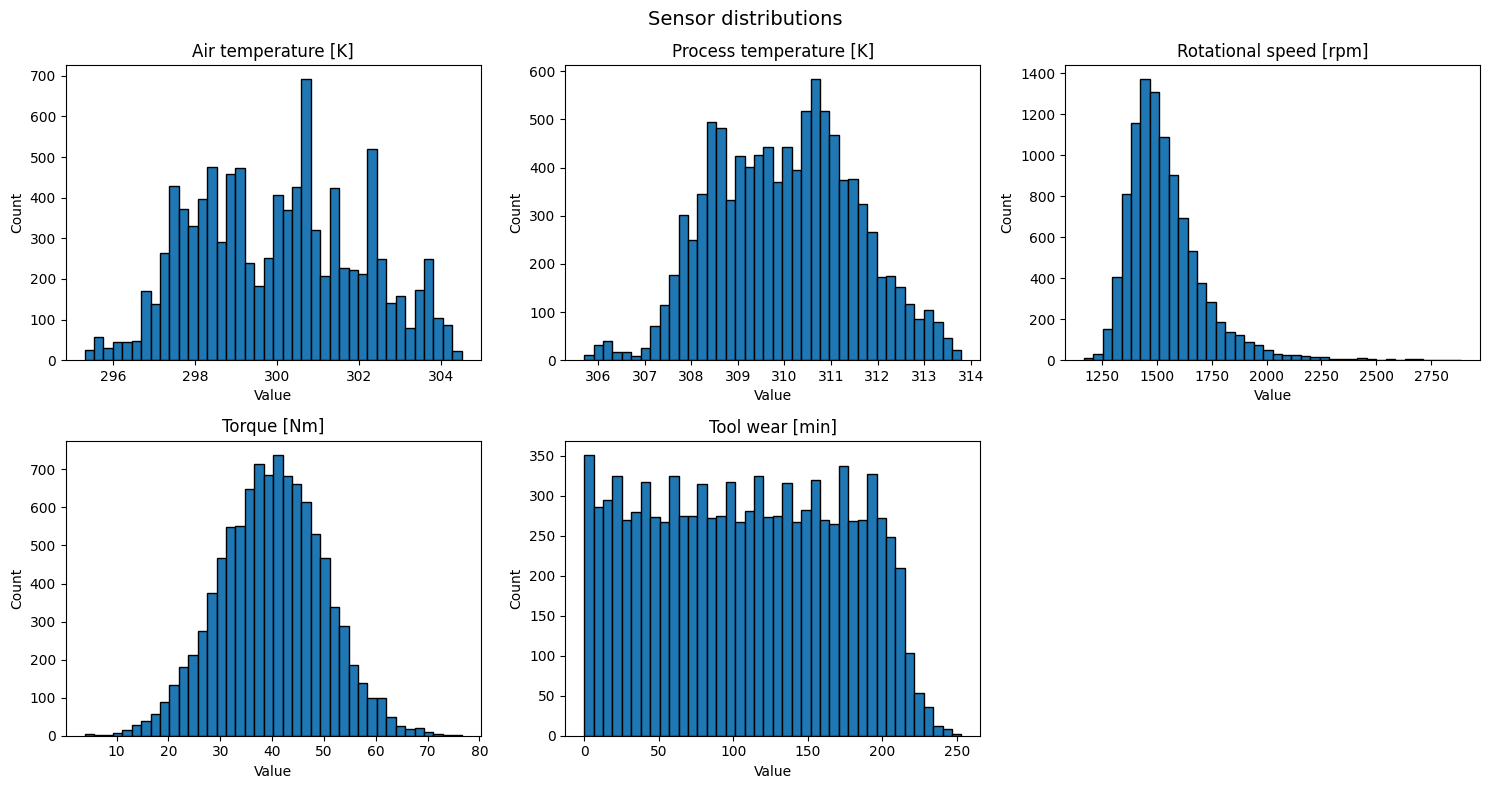

In [15]:
sensors = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))
fig.suptitle('Sensor distributions', fontsize=14)

for i, col in enumerate(sensors):
    ax = axes[i//3][i%3]
    ax.hist(df[col], bins=40, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

axes[1][2].set_visible(False)  # hide empty subplot
plt.tight_layout()
plt.show()

In [16]:
# Sensor values during failure vs no failure
for col in sensors:
    means = df.groupby('Machine failure')[col].mean()
    print(f"{col}: no failure={means[0]:.1f} | failure={means[1]:.1f} | diff={means[1]-means[0]:.1f}")

Air temperature [K]: no failure=300.0 | failure=300.9 | diff=0.9
Process temperature [K]: no failure=310.0 | failure=310.3 | diff=0.3
Rotational speed [rpm]: no failure=1540.3 | failure=1496.5 | diff=-43.8
Torque [Nm]: no failure=39.6 | failure=50.2 | diff=10.5
Tool wear [min]: no failure=106.7 | failure=143.8 | diff=37.1


In [17]:
# Machine type breakdown
print(df['Type'].value_counts())
print()
print(df.groupby('Type')['Machine failure'].mean().round(3))

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Type
H    0.021
L    0.039
M    0.028
Name: Machine failure, dtype: float64


# Correlation

In [18]:
corr = df.corr(numeric_only=True)['Machine failure'].sort_values(ascending=False)
print(corr)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


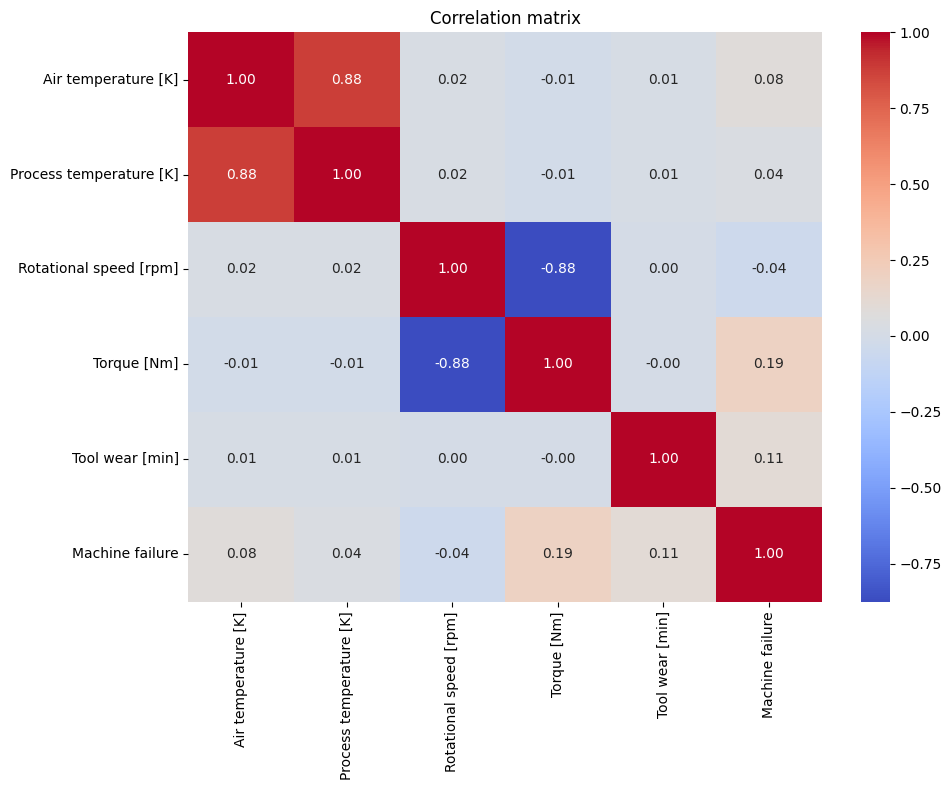

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[sensors + ['Machine failure']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()